# 📈 Linear Regression - The Practical Guide

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/project-nabula/blob/main/notebooks/regression/01_linear_regression.ipynb)
[![GitHub](https://img.shields.io/badge/GitHub-Repository-blue)](https://github.com/muhammadtalhaishtiaq/project-nabula)

---

## 🎯 What You'll Learn

| Step | Skill | Time |
|------|-------|------|
| 1 | Load & explore data | 2 min |
| 2 | Train a model (3 lines of code!) | 1 min |
| 3 | Interpret coefficients & metrics | 5 min |
| 4 | Visualize results | 3 min |
| 5 | Make predictions | 2 min |

**Total: ~15 minutes** to go from data to predictions

---

> 💡 **Real Talk**: In industry, you'll use sklearn 99% of the time. This notebook teaches you what matters: **interpreting results and making decisions**.

## 📚 What is Linear Regression?

Linear Regression is a **supervised learning algorithm** that models the relationship between a dependent variable (y) and one or more independent variables (X) by fitting a linear equation.

### The Equation

$$y = mx + b$$

Or in ML notation:

$$\hat{y} = w_1x + w_0$$

Where:
- $\hat{y}$ = Predicted value
- $w_1$ = Slope (weight/coefficient)
- $w_0$ = Intercept (bias)
- $x$ = Input feature

### How Does It Learn?

The algorithm finds the **best-fit line** by minimizing the **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### When to Use It

✅ **Use Linear Regression when:**
- Target is continuous (numbers, not categories)
- You expect a roughly linear relationship
- You need interpretable results ("each year adds $5k")

❌ **Don't use when:**
- Target is categorical (use Logistic Regression)
- Relationship is clearly non-linear (use Polynomial/Tree models)
- You have complex feature interactions (use ensemble methods)

### Real-World Applications

| Domain | Use Case |
|--------|----------|
| 🏠 Real Estate | Predict house prices based on size |
| 💰 Finance | Stock price prediction |
| 🏥 Healthcare | Drug dosage based on weight |
| 📊 Marketing | Ad spend vs. sales revenue |

---
## 🛠️ Step 1: Setup & Load Data

In [6]:
# Standard imports - this is what you'll use in every ML project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Ready to go!")

✅ Ready to go!


In [7]:
# Create a realistic dataset: Employee Experience vs Salary
# In real projects, you'd load this from CSV: pd.read_csv('salary_data.csv')

n_samples = 100
experience = np.random.uniform(1, 15, n_samples)  # 1-15 years
salary = 30000 + 5000 * experience + np.random.normal(0, 5000, n_samples)  # Base + growth + noise

# Create DataFrame (how you'll typically work with data)
df = pd.DataFrame({
    'years_experience': experience,
    'salary': salary
})

# Quick data exploration
print("📊 Dataset Overview:")
print(df.describe().round(2))
print(f"\n🔍 First 5 rows:")
df.head()

📊 Dataset Overview:
       years_experience     salary
count            100.00     100.00
mean               7.58   67907.25
std                4.16   20639.84
min                1.08   33568.79
25%                3.70   50368.36
50%                7.50   65504.72
75%               11.22   86495.45
max               14.82  107991.20

🔍 First 5 rows:


,years_experience,salary
0,6.243562,61653.043661
1,14.310000,100054.964696
2,11.247915,86698.379809
3,9.381219,66968.249321
4,3.184261,44822.945392


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128161 (\N{ELECTRIC LIGHT BULB}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


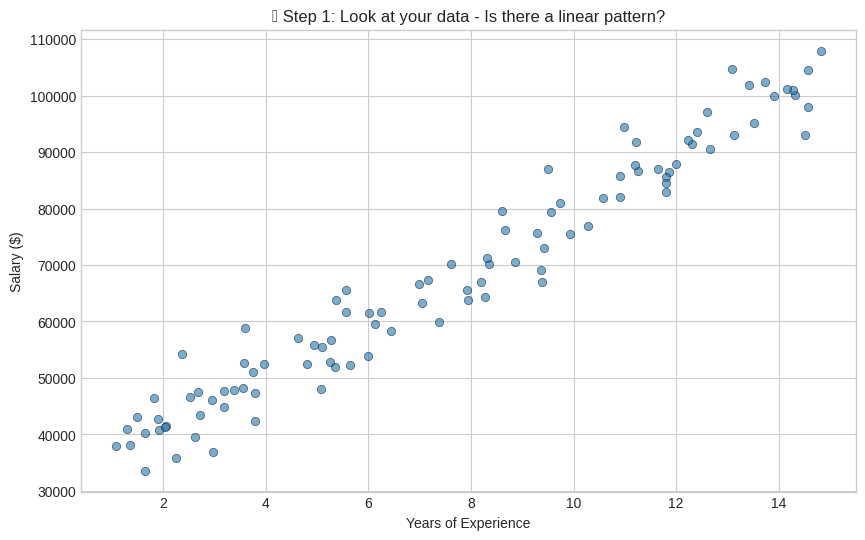

In [8]:
# Always visualize your data BEFORE modeling
plt.figure(figsize=(10, 6))
plt.scatter(df['years_experience'], df['salary'], alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.title('💡 Step 1: Look at your data - Is there a linear pattern?')
plt.show()

# Answer: Yes! Clear upward trend = Linear Regression is appropriate

In [18]:
# Prepare features (X) and target (y)
X = df[['years_experience']]  # Double brackets = DataFrame (sklearn prefers this)
y = df['salary']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📦 Train: {len(X_train)} samples | Test: {len(X_test)} samples")

📦 Train: 80 samples | Test: 20 samples


---
## 🚀 Step 2: Train the Model (3 lines!)

In [10]:
# This is it. This is what you do in practice.
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("✅ Model trained!")

✅ Model trained!


---
## 📊 Step 3: Interpret the Results (THE IMPORTANT PART)

In [15]:
# THE COEFFICIENTS - This is what your stakeholders care about!
slope = model.coef_[0]
intercept = model.intercept_

print("="*50)
print("💰 BUSINESS INTERPRETATION")
print("="*50)
print(f"\n📈 Slope (coef_): ${slope:,.0f}")
print(f"   → Each additional year of experience = ${slope:,.0f} higher salary")
print(f"\n📍 Intercept: ${intercept:,.0f}")
print(f"   → Baseline salary for 0 years experience")
print(f"\n🔮 Formula: Salary = ${slope:,.0f} × Experience + ${intercept:,.0f}")
print("="*50)

💰 BUSINESS INTERPRETATION

📈 Slope (coef_): $4,857
   → Each additional year of experience = $4,857 higher salary

📍 Intercept: $30,858
   → Baseline salary for 0 years experience

🔮 Formula: Salary = $4,857 × Experience + $30,858


In [13]:
# MODEL PERFORMANCE METRICS
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("📏 MODEL PERFORMANCE")
print("-"*50)
print(f"R² Score:  {r2:.3f}  → Model explains {r2*100:.1f}% of salary variance")
print(f"RMSE:      ${rmse:,.0f}  → Average prediction is off by ~${rmse:,.0f}")
print(f"MAE:       ${mae:,.0f}  → Typical error magnitude")
print("-"*50)

# Quick interpretation
if r2 > 0.8:
    print("✅ Strong model! R² > 0.8")
elif r2 > 0.5:
    print("🟡 Moderate model. Consider adding more features.")
else:
    print("❌ Weak model. Linear relationship may not exist.")

📏 MODEL PERFORMANCE
--------------------------------------------------
R² Score:  0.964  → Model explains 96.4% of salary variance
RMSE:      $4,043  → Average prediction is off by ~$4,043
MAE:       $2,957  → Typical error magnitude
--------------------------------------------------
✅ Strong model! R² > 0.8


---
## 📈 Step 4: Visualize (Show Your Work)

/tmp/ipython-input-415929605.py:32: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-415929605.py:32: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-415929605.py:32: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) 

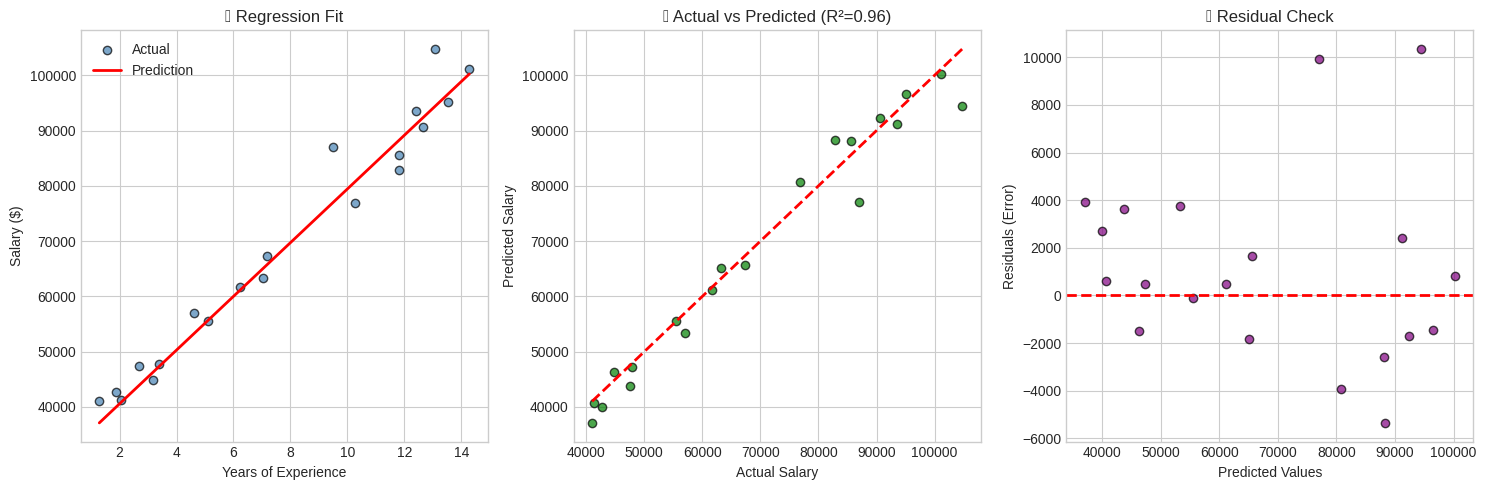


💡 If residuals show a pattern, linear regression isn't the right choice.


In [16]:
# The visualization you'll show in presentations
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Regression Line
ax1 = axes[0]
ax1.scatter(X_test, y_test, alpha=0.7, label='Actual', c='steelblue', edgecolors='black')
ax1.plot(X_test.sort_values('years_experience'), 
         model.predict(X_test.sort_values('years_experience')), 
         'r-', linewidth=2, label='Prediction')
ax1.set_xlabel('Years of Experience')
ax1.set_ylabel('Salary ($)')
ax1.set_title('📈 Regression Fit')
ax1.legend()

# 2. Actual vs Predicted (most important diagnostic)
ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.7, c='green', edgecolors='black')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax2.set_xlabel('Actual Salary')
ax2.set_ylabel('Predicted Salary')
ax2.set_title(f'🎯 Actual vs Predicted (R²={r2:.2f})')

# 3. Residuals (errors should be random around 0)
ax3 = axes[2]
residuals = y_test - y_pred
ax3.scatter(y_pred, residuals, alpha=0.7, c='purple', edgecolors='black')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Predicted Values')
ax3.set_ylabel('Residuals (Error)')
ax3.set_title('📉 Residual Check')

plt.tight_layout()
plt.show()

print("\n💡 If residuals show a pattern, linear regression isn't the right choice.")

---
## 🔮 Step 5: Make Predictions

In [17]:
# Predict salary for new candidates
new_candidates = pd.DataFrame({'years_experience': [2, 5, 10, 15]})
predictions = model.predict(new_candidates)

print("🔮 SALARY PREDICTIONS")
print("-"*40)
for exp, sal in zip(new_candidates['years_experience'], predictions):
    print(f"   {exp:2} years experience → ${sal:,.0f}")
print("-"*40)

🔮 SALARY PREDICTIONS
----------------------------------------
    2 years experience → $40,571
    5 years experience → $55,141
   10 years experience → $79,425
   15 years experience → $103,708
----------------------------------------


---
## ✅ Summary: The Complete Workflow

```python
# 1. Load data
df = pd.read_csv('your_data.csv')

# 2. Prepare features
X = df[['feature1', 'feature2']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. Train
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluate
print(f"R² = {model.score(X_test, y_test):.3f}")
print(f"Coefficients: {model.coef_}")

# 5. Predict
model.predict([[new_value1, new_value2]])
```

### When to Move Beyond Linear Regression

| Symptom | Try Instead |
|---------|-------------|
| Curved pattern in residuals | Polynomial Regression |
| Many features, overfitting | Ridge/Lasso Regression |
| Non-linear relationships | Decision Trees, Random Forest |
| Classification problem | Logistic Regression |

---

## 🔗 Further Reading

- [Scikit-learn LinearRegression Docs](https://scikit-learn.org/stable/modules/linear_model.html)
- [StatQuest: Linear Regression (YouTube)](https://www.youtube.com/watch?v=nk2CQITm_eo)

---

### 🚀 Next Up: [Multiple Linear Regression →](./02_multiple_linear_regression.ipynb)

---

<div align="center">
  <strong>⭐ Star this repo if it helped!</strong><br>
  <a href="https://github.com/muhammadtalhaishtiaq/project-nabula">GitHub Repository</a>
</div>